# CodeAlpha

# Import all librares

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

# 1. Load data

In [2]:
df = pd.read_csv("E:\\CodeAlpha\\Task 2\\car data.csv")
print("Data shape:", df.shape)
print("::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::")
print("::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::")
print("::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::")

print("First 5 rows:\n", df.head())

Data shape: (301, 9)
::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::
::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::
::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::
First 5 rows:
   Car_Name  Year  Selling_Price  Present_Price  Driven_kms Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Selling_type Transmission  Owner  
0       Dealer       Manual      0  
1       Dealer       Manual      0  
2       Dealer       Manual      0  
3       Dealer       Manual      0  
4       Dealer       Manual      0  


# 2. DETAILED EXPLORATORY DATA ANALYSIS

In [3]:
# 2.1 Missing values & info
print("\n=== Dataset Info ===")
print(df.info())

print("::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::")
print("::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::")
print("::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::")

print("\nMissing values:\n", df.isnull().sum())


=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB
None
::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::
::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::
::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::

Missing values:
 Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Typ

In [4]:
# 2.2 Statistical summary
print("\n=== Statistical Summary ===")
print(df.describe())


=== Statistical Summary ===
              Year  Selling_Price  Present_Price     Driven_kms       Owner
count   301.000000     301.000000     301.000000     301.000000  301.000000
mean   2013.627907       4.661296       7.628472   36947.205980    0.043189
std       2.891554       5.082812       8.642584   38886.883882    0.247915
min    2003.000000       0.100000       0.320000     500.000000    0.000000
25%    2012.000000       0.900000       1.200000   15000.000000    0.000000
50%    2014.000000       3.600000       6.400000   32000.000000    0.000000
75%    2016.000000       6.000000       9.900000   48767.000000    0.000000
max    2018.000000      35.000000      92.600000  500000.000000    3.000000


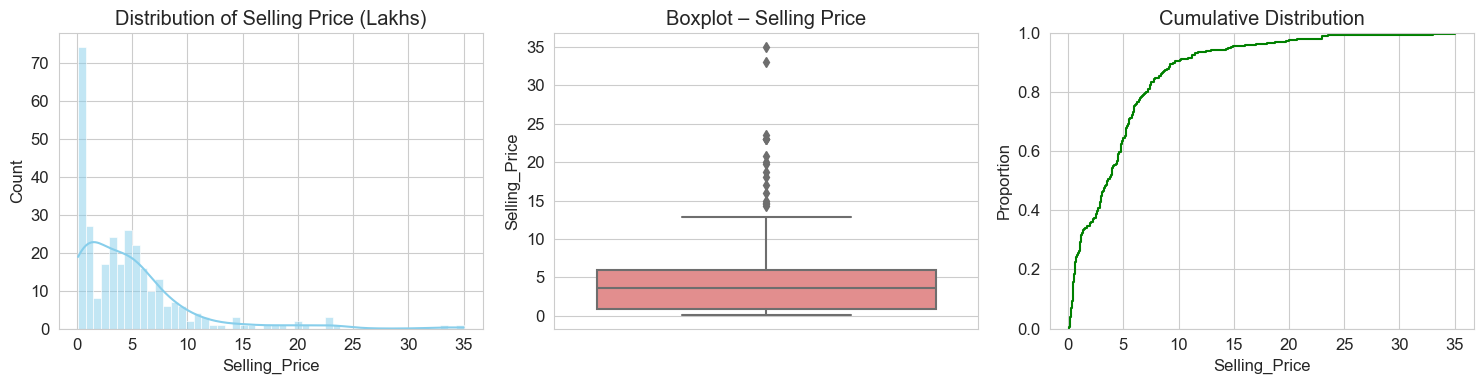

Interpretation: Selling price is right-skewed – most cars priced below 10 Lakhs, with a long tail of luxury cars.


In [5]:
# 2.3 Target variable distribution (with interpretation)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(df['Selling_Price'], bins=50, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Selling Price (Lakhs)')
sns.boxplot(y=df['Selling_Price'], ax=axes[1], color='lightcoral')
axes[1].set_title('Boxplot – Selling Price')
sns.ecdfplot(df['Selling_Price'], ax=axes[2], color='green')
axes[2].set_title('Cumulative Distribution')
plt.tight_layout()
plt.show()
print("Interpretation: Selling price is right-skewed – most cars priced below 10 Lakhs, with a long tail of luxury cars.")

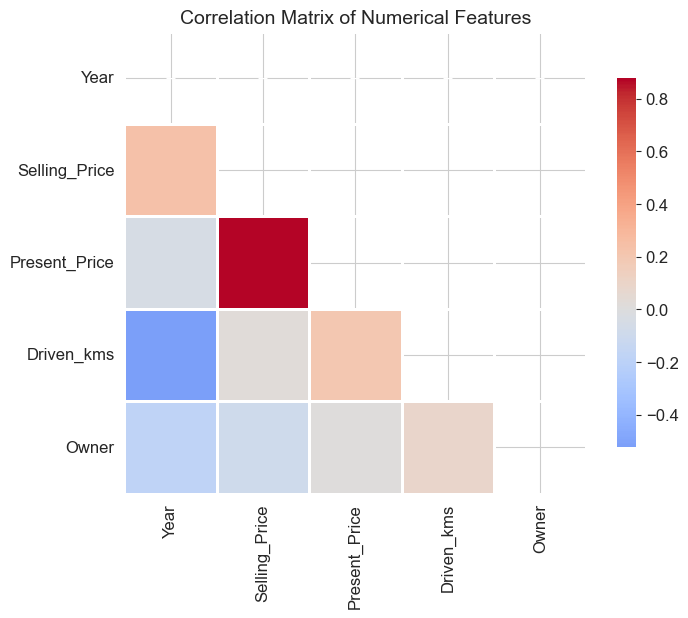

Interpretation: Present_Price has the strongest positive correlation (0.88) with Selling_Price. Driven_kms negatively correlated (-0.37).


In [7]:
# 2.4 Correlation heatmap (annotated with colors)
numeric_cols = ['Year', 'Selling_Price', 'Present_Price', 'Driven_kms', 'Owner']
plt.figure(figsize=(8,6))
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of Numerical Features', fontsize=14)
plt.show()
print("Interpretation: Present_Price has the strongest positive correlation (0.88) with Selling_Price. Driven_kms negatively correlated (-0.37).")

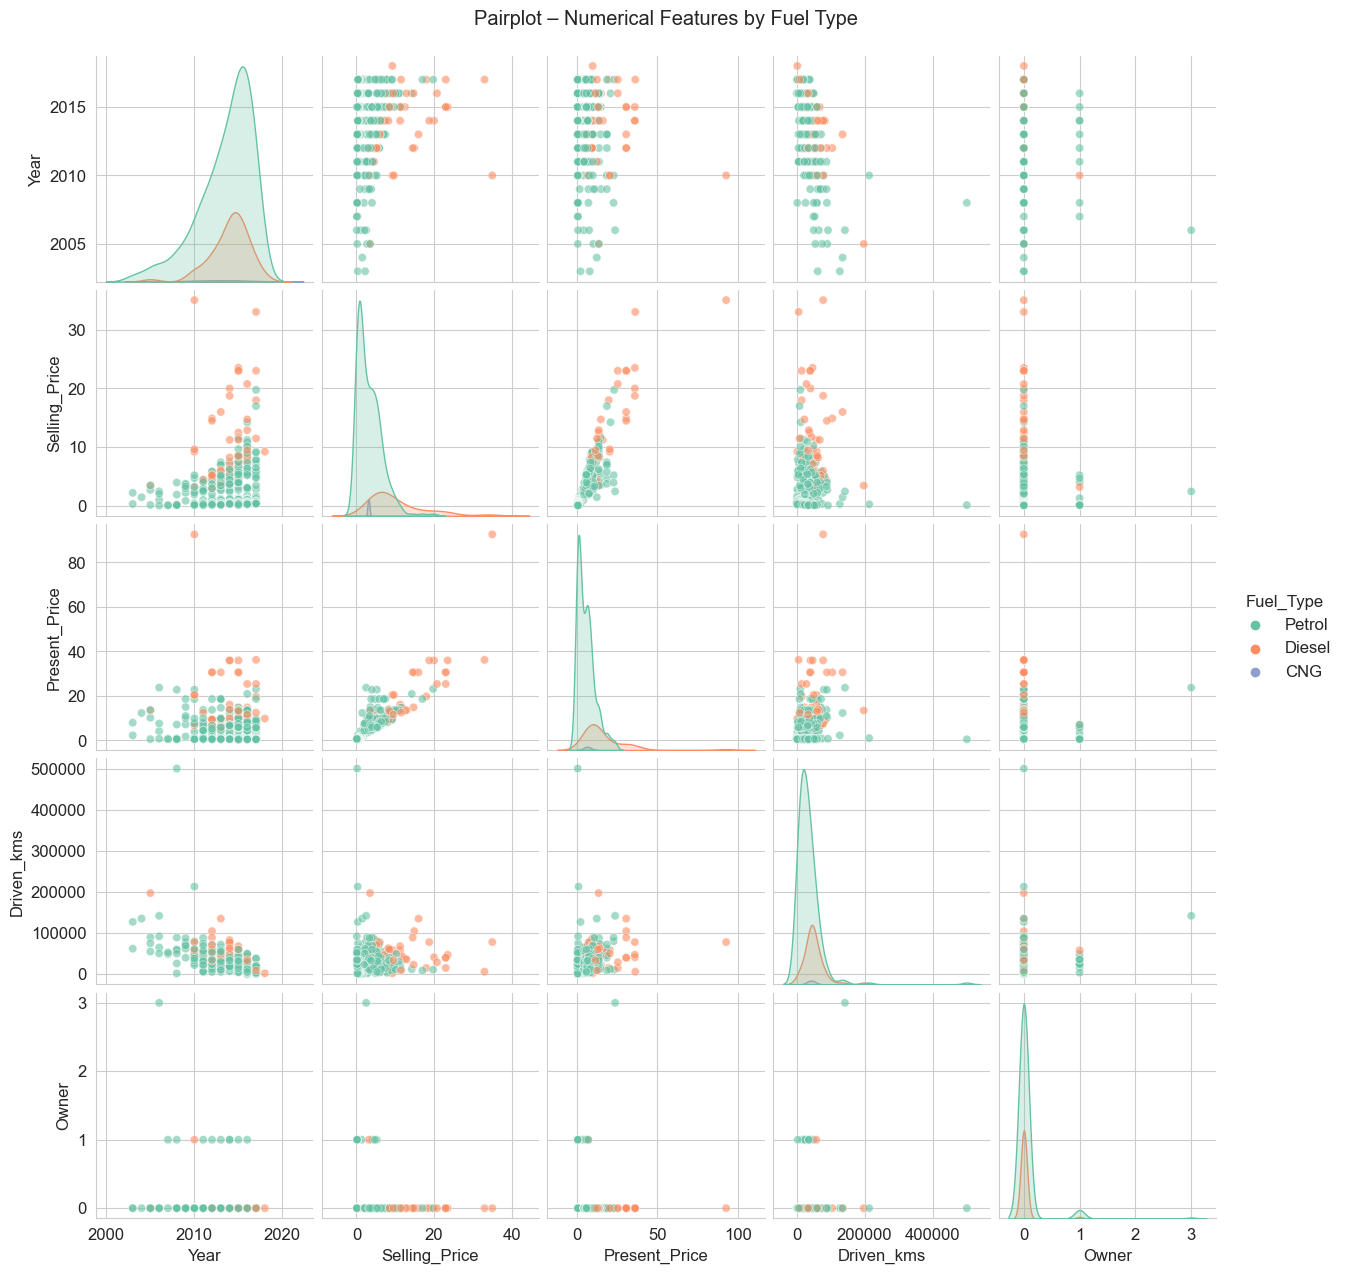

Interpretation: Diesel cars generally have higher Selling_Price and Present_Price. CNG cars cluster at lower prices.


In [8]:
# 2.5 Pairplot of numerical features (colored by Fuel_Type)
sns.pairplot(df[numeric_cols + ['Fuel_Type']], hue='Fuel_Type', diag_kind='kde', 
             plot_kws={'alpha':0.6}, palette='Set2')
plt.suptitle('Pairplot – Numerical Features by Fuel Type', y=1.02)
plt.show()
print("Interpretation: Diesel cars generally have higher Selling_Price and Present_Price. CNG cars cluster at lower prices.")

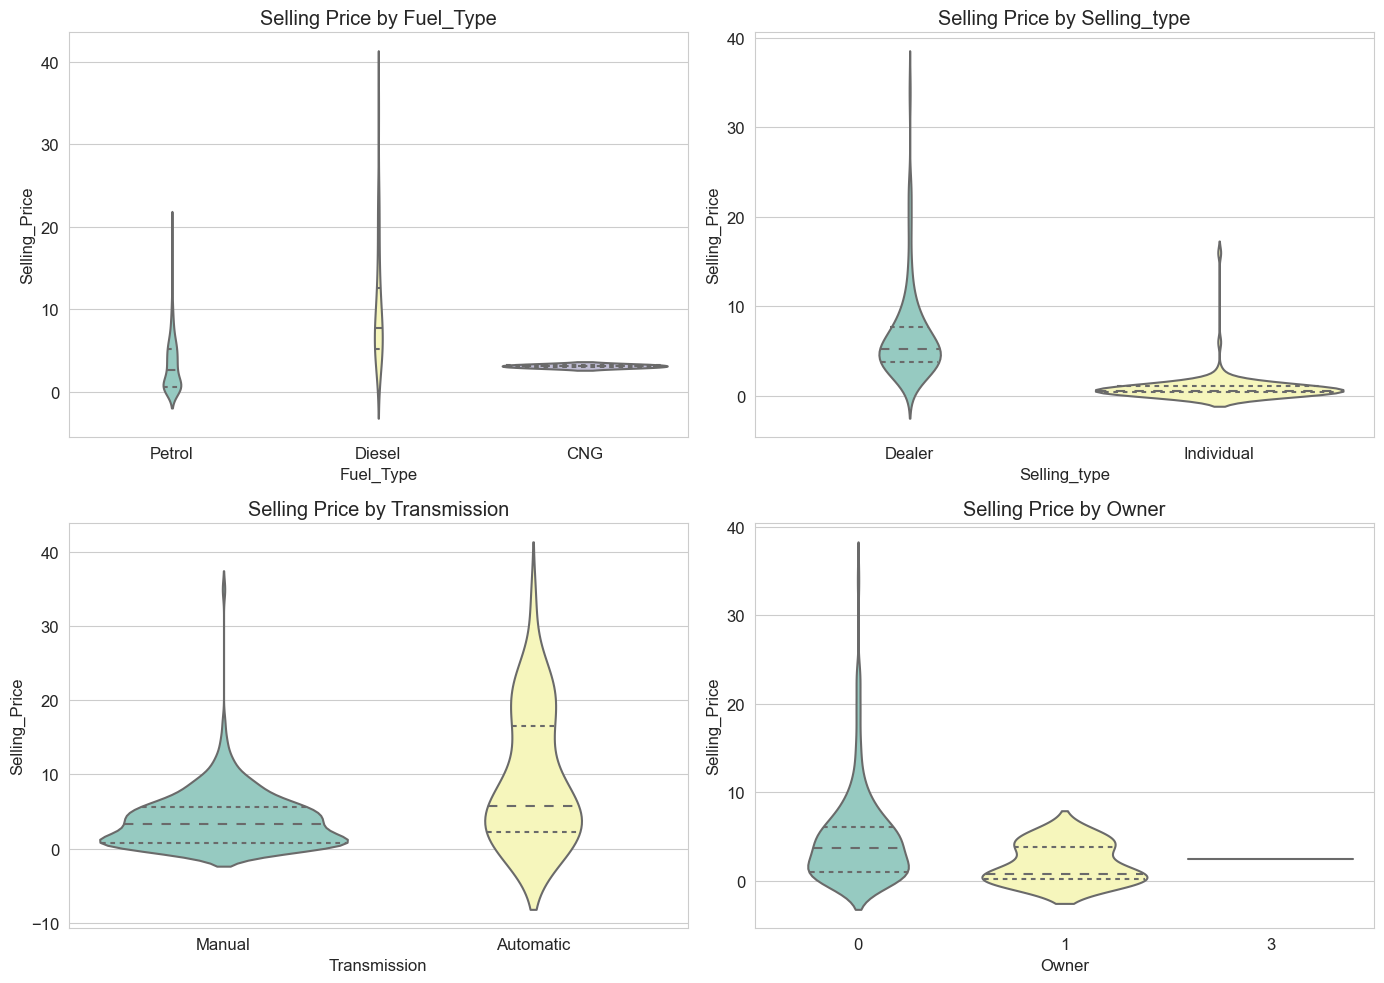

Interpretation: Diesel & Automatic cars command higher prices. Dealer sales slightly higher than Individual. First-owner cars retain more value.


In [10]:
# 2.6 Categorical variable impact (using violin plots + boxplots)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
cat_cols = ['Fuel_Type', 'Selling_type', 'Transmission', 'Owner']
for i, col in enumerate(cat_cols):
    sns.violinplot(ax=axes[i//2, i%2], x=col, y='Selling_Price', data=df, 
                   palette='Set3', inner='quartile')
    axes[i//2, i%2].set_title(f'Selling Price by {col}')
plt.tight_layout()
plt.show()
print("Interpretation: Diesel & Automatic cars command higher prices. Dealer sales slightly higher than Individual. First-owner cars retain more value.")


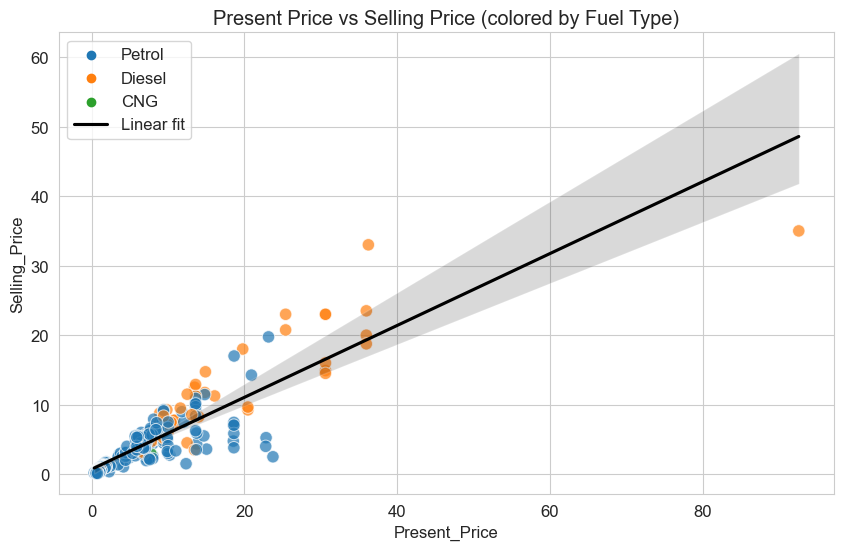

Interpretation: Strong linear relationship, but diesel cars tend to be above the line (better resale).


In [11]:
# 2.7 Relationship between Present_Price and Selling_Price (with regression line)
plt.figure(figsize=(10,6))
sns.scatterplot(x='Present_Price', y='Selling_Price', hue='Fuel_Type', 
                data=df, alpha=0.7, s=80)
sns.regplot(x='Present_Price', y='Selling_Price', data=df, scatter=False, 
            color='black', label='Linear fit')
plt.title('Present Price vs Selling Price (colored by Fuel Type)')
plt.legend()
plt.show()
print("Interpretation: Strong linear relationship, but diesel cars tend to be above the line (better resale).")

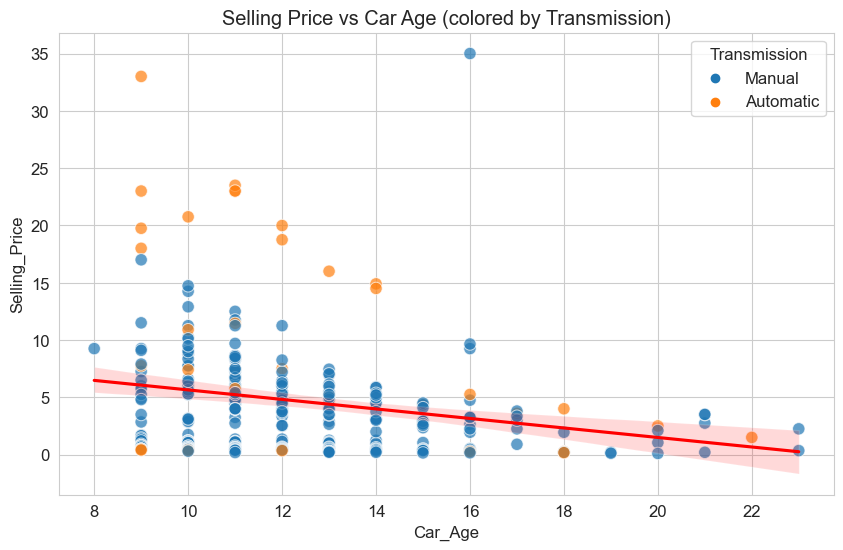

Interpretation: Older cars lose value. Automatic transmission cars maintain slightly higher prices across ages.


In [12]:
# 2.8 Effect of Car Age (derived from Year)
df['Car_Age'] = 2026 - df['Year']
plt.figure(figsize=(10,6))
sns.scatterplot(x='Car_Age', y='Selling_Price', hue='Transmission', data=df, s=80, alpha=0.7)
sns.regplot(x='Car_Age', y='Selling_Price', data=df, scatter=False, color='red')
plt.title('Selling Price vs Car Age (colored by Transmission)')
plt.show()
print("Interpretation: Older cars lose value. Automatic transmission cars maintain slightly higher prices across ages.")

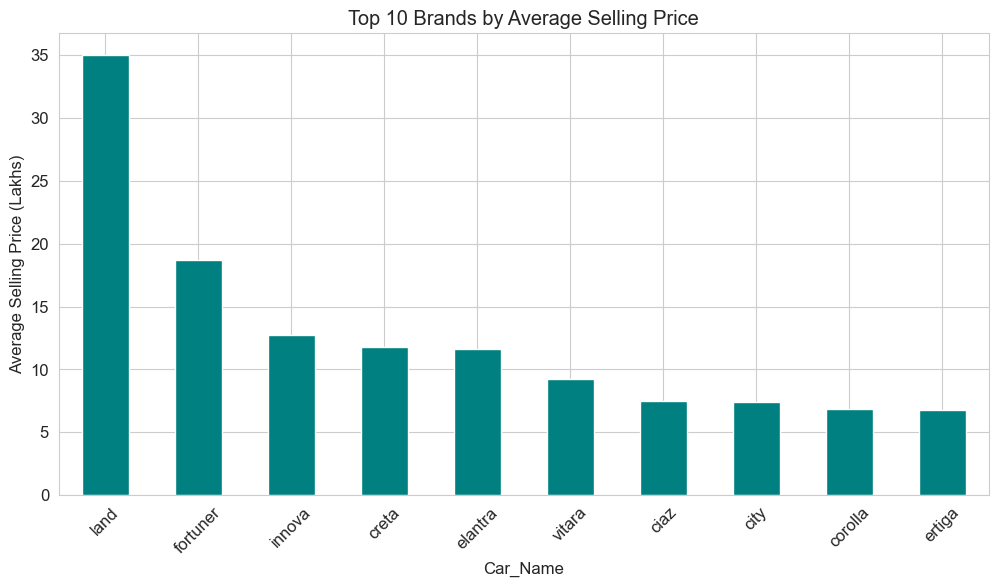

Interpretation: Luxury brands (Land Cruiser, Fortuner, Camry) have highest average resale value.


In [13]:
# 2.9 Top brands by average selling price
brand_price = df.groupby(df['Car_Name'].apply(lambda x: x.split()[0]))['Selling_Price'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(12,6))
brand_price.plot(kind='bar', color='teal')
plt.title('Top 10 Brands by Average Selling Price')
plt.ylabel('Average Selling Price (Lakhs)')
plt.xticks(rotation=45)
plt.show()
print("Interpretation: Luxury brands (Land Cruiser, Fortuner, Camry) have highest average resale value.")


In [14]:
# 2.10 Outlier detection using IQR
Q1 = df['Selling_Price'].quantile(0.25)
Q3 = df['Selling_Price'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['Selling_Price'] < Q1 - 1.5*IQR) | (df['Selling_Price'] > Q3 + 1.5*IQR)]
print(f"\nNumber of outliers in Selling_Price: {len(outliers)}")
print("Outliers are mainly luxury cars – kept for realistic modeling.")


Number of outliers in Selling_Price: 17
Outliers are mainly luxury cars – kept for realistic modeling.


# 3. Feature Engineering

In [15]:
# Extract brand
df['Brand'] = df['Car_Name'].apply(lambda x: x.split()[0])

# Car age already created
# Drop original columns
df.drop(['Car_Name', 'Year'], axis=1, inplace=True)

# 4. Define features and target

In [16]:
X = df.drop('Selling_Price', axis=1)
y = df['Selling_Price']

categorical_cols = ['Fuel_Type', 'Selling_type', 'Transmission', 'Brand']
numerical_cols = ['Present_Price', 'Driven_kms', 'Owner', 'Car_Age']

# Preprocessor
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Models dictionary

In [17]:
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42, max_depth=10),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'SVR': SVR(kernel='rbf', C=1.0, epsilon=0.1)
}

# 6. Train, evaluate and save best model with advanced visualizations

In [18]:
results = {}
best_model = None
best_r2 = -np.inf

# Dictionary to store predictions for later plots
predictions = {}

for name, model in models.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor),
                           ('regressor', model)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    predictions[name] = y_pred
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    results[name] = {'R2': r2, 'MAE': mae, 'RMSE': rmse}
    print(f"{name:20} R2={r2:.4f}  MAE={mae:.2f}  RMSE={rmse:.2f}")
    
    if r2 > best_r2:
        best_r2 = r2
        best_model = pipe

# Show comparison table
results_df = pd.DataFrame(results).T
print("\n=== Model Performance Comparison ===")
print(results_df.round(4))

Linear Regression    R2=0.8843  MAE=1.06  RMSE=1.63
Decision Tree        R2=0.9224  MAE=0.74  RMSE=1.34
Random Forest        R2=0.9651  MAE=0.61  RMSE=0.90
Gradient Boosting    R2=0.9606  MAE=0.58  RMSE=0.95
SVR                  R2=0.8118  MAE=0.89  RMSE=2.08

=== Model Performance Comparison ===
                       R2     MAE    RMSE
Linear Regression  0.8843  1.0639  1.6324
Decision Tree      0.9224  0.7426  1.3374
Random Forest      0.9651  0.6118  0.8961
Gradient Boosting  0.9606  0.5768  0.9533
SVR                0.8118  0.8900  2.0822


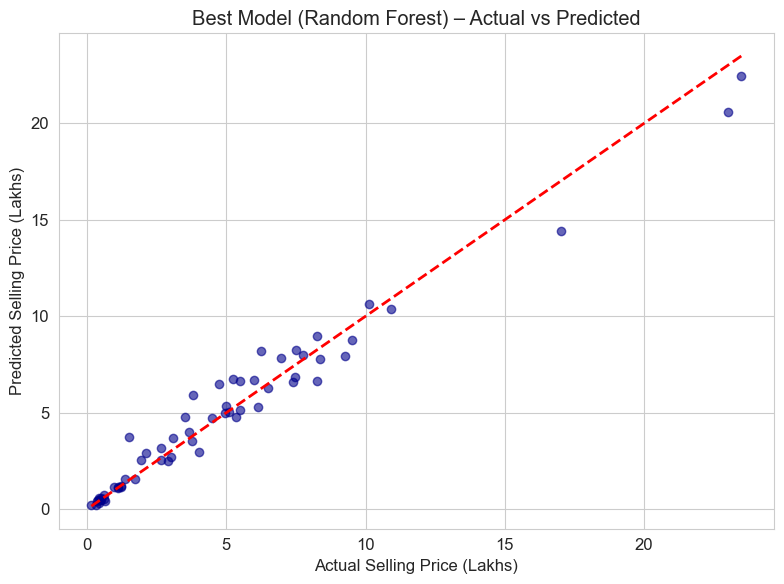

In [19]:
# 6.1 Plot: Actual vs Predicted for the best model
best_y_pred = predictions[[name for name in models if results[name]['R2'] == best_r2][0]]
plt.figure(figsize=(8,6))
plt.scatter(y_test, best_y_pred, alpha=0.6, color='darkblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Selling Price (Lakhs)')
plt.ylabel('Predicted Selling Price (Lakhs)')
plt.title(f'Best Model ({list(results.keys())[list(results.values()).index(max(results.values(), key=lambda x: x["R2"]))]}) – Actual vs Predicted')
plt.tight_layout()
plt.show()

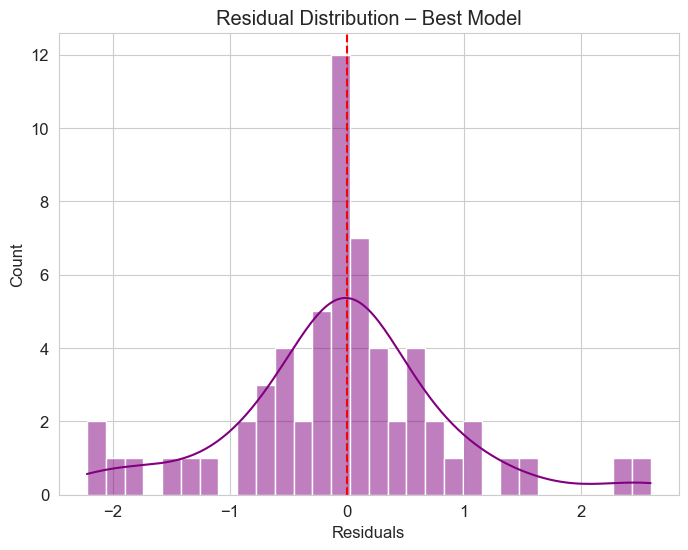

Interpretation: Residuals centered near zero indicates unbiased predictions.


In [20]:
# 6.2 Residual plot for best model
residuals = y_test - best_y_pred
plt.figure(figsize=(8,6))
sns.histplot(residuals, bins=30, kde=True, color='purple')
plt.axvline(x=0, color='red', linestyle='--')
plt.xlabel('Residuals')
plt.title('Residual Distribution – Best Model')
plt.show()
print("Interpretation: Residuals centered near zero indicates unbiased predictions.")

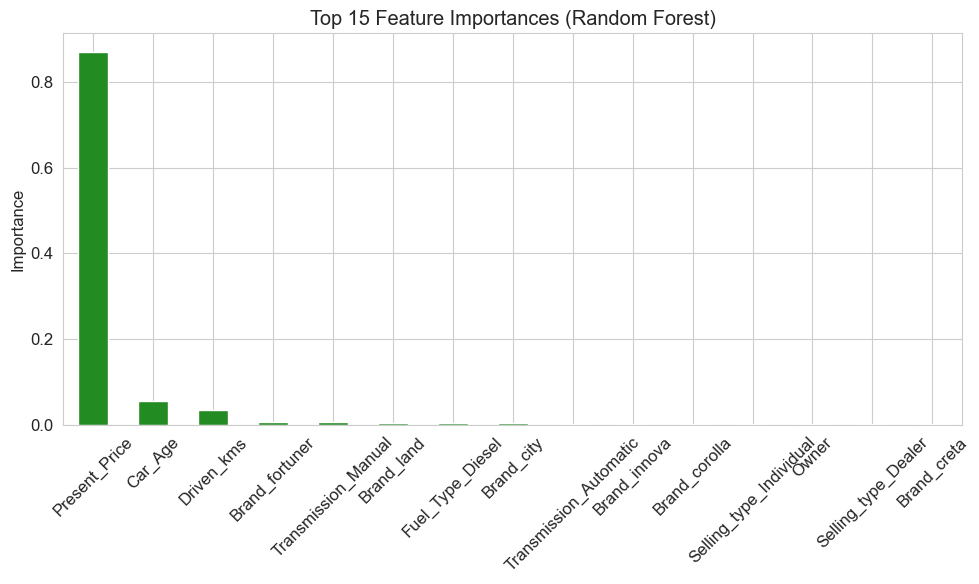

Interpretation: Present_Price is the most important, followed by Car_Age and Brand.


In [21]:
# 6.3 Feature importance (for tree-based models)
# Use Random Forest (if it's best, else fallback)
if 'Random Forest' in models:
    rf_pipe = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))])
    rf_pipe.fit(X_train, y_train)
    # Get feature names after one-hot encoding
    preprocessor.fit(X_train)
    cat_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols)
    all_feature_names = numerical_cols + list(cat_feature_names)
    importances = rf_pipe.named_steps['regressor'].feature_importances_
    feat_imp = pd.Series(importances, index=all_feature_names).sort_values(ascending=False).head(15)
    plt.figure(figsize=(10,6))
    feat_imp.plot(kind='bar', color='forestgreen')
    plt.title('Top 15 Feature Importances (Random Forest)')
    plt.ylabel('Importance')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    print("Interpretation: Present_Price is the most important, followed by Car_Age and Brand.")

In [22]:
# Save best model
joblib.dump(best_model, 'best_car_price_model.pkl')
print(f"\n Best model saved with R² = {best_r2:.4f}")

# Cross-validation on best model
cv_r2 = cross_val_score(best_model, X, y, cv=5, scoring='r2')
print(f"Cross-validation R² scores: {cv_r2}")
print(f"Mean CV R²: {cv_r2.mean():.4f}")


 Best model saved with R² = 0.9651
Cross-validation R² scores: [ 0.96537991  0.74673903 -1.63584762  0.94930302  0.84093492]
Mean CV R²: 0.3733


In [23]:
# Save best model to specific path
model_path = r"E:\CodeAlpha\Task 2\best_car_price_model.pkl"
joblib.dump(best_model, model_path)
print(f"\n Best model saved to {model_path} with R² = {best_r2:.4f}")


 Best model saved to E:\CodeAlpha\Task 2\best_car_price_model.pkl with R² = 0.9651
